In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

In [7]:
df = pd.read_csv("../AB_NYC_2019.csv")

In [8]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [9]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (48895, 16)
<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review     

In [10]:
df.describe(include="all")

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [11]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing values in each column:
name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64


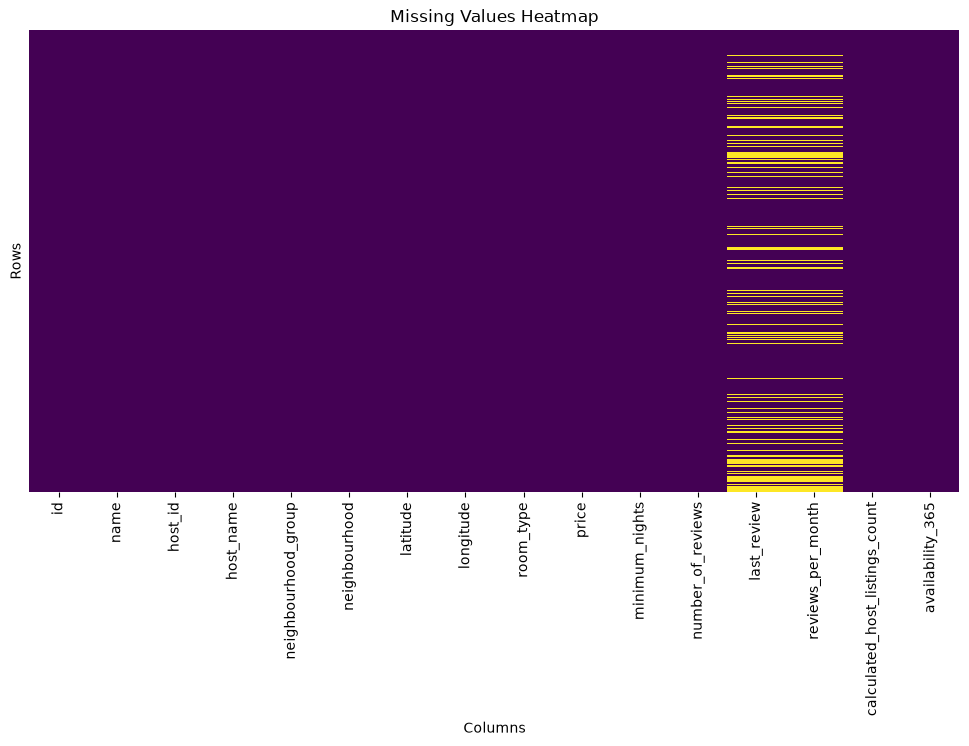

In [12]:
# Missing value analysis
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [14]:
#duplicate rows
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate listing IDs:", df["id"].duplicated().sum())

Duplicate rows: 0
Duplicate listing IDs: 0


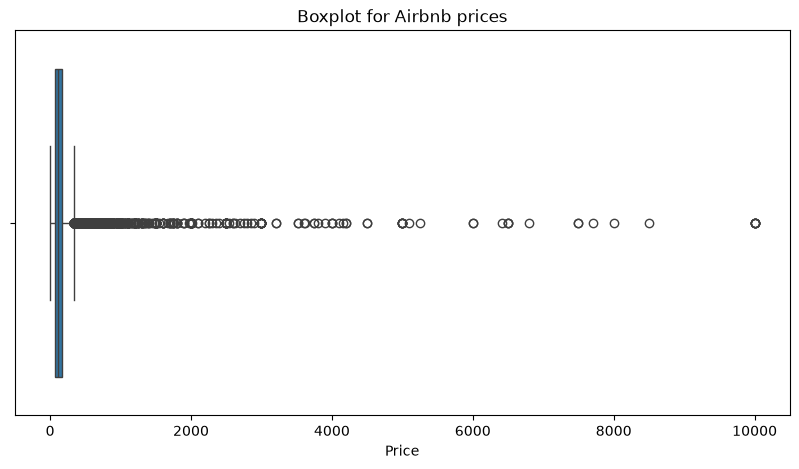

In [18]:
#Checking outliers
plt.figure(figsize=(10,5))
sns.boxplot(x=df["price"])
plt.title("Boxplot for Airbnb prices")
plt.xlabel("Price")
plt.show()

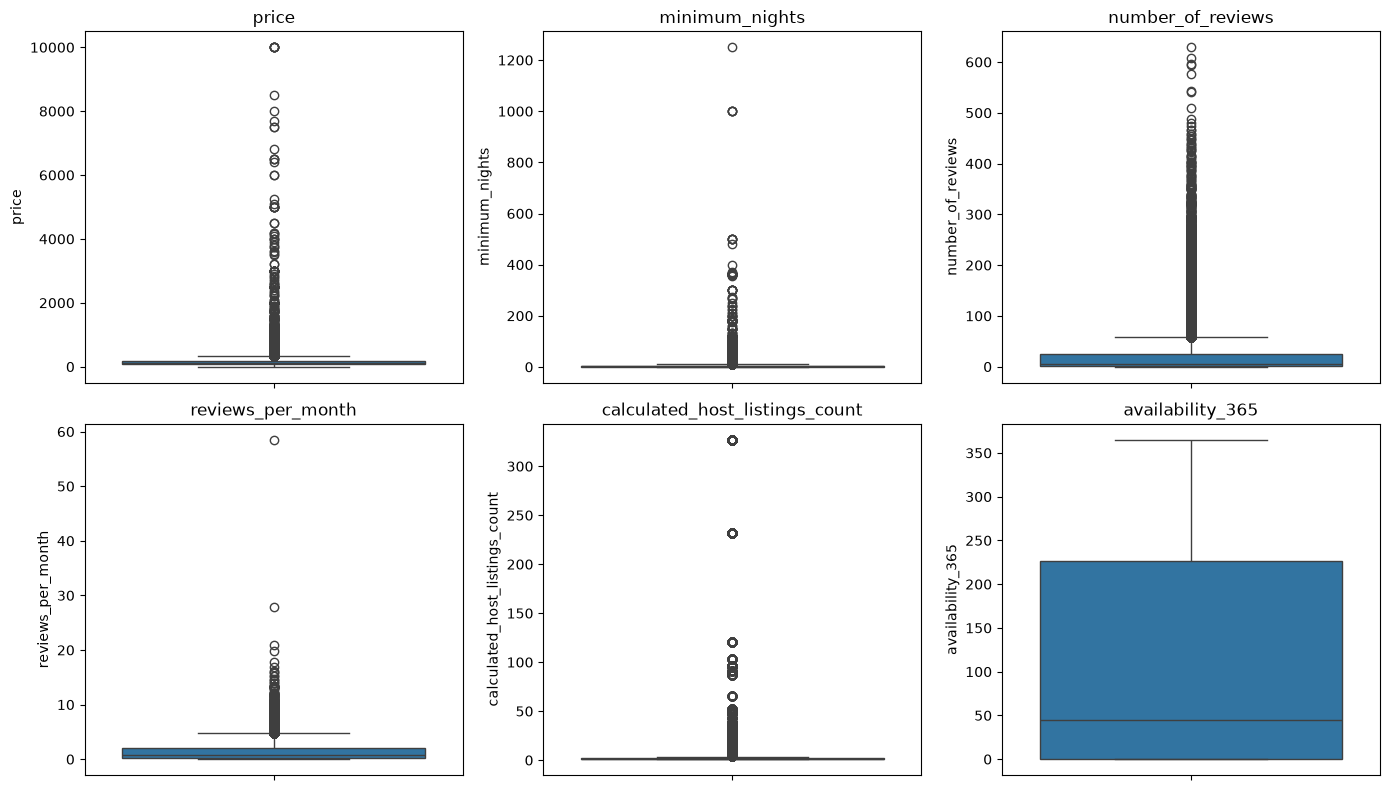

In [21]:
#boxplot for numeric values
numeric_features = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]
plt.figure(figsize=(14,8))

for i, column in enumerate(numeric_features,1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()    

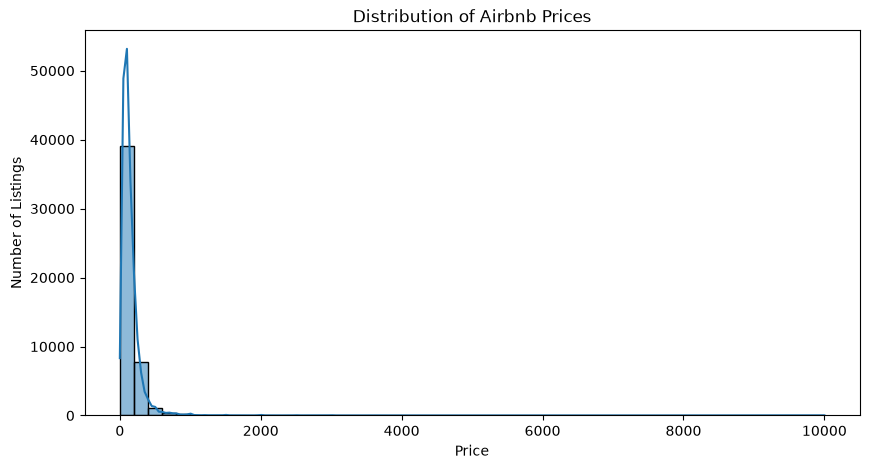

In [24]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.show()

In [25]:
print(df["price"].describe())

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


In [26]:
print("Price = 0:", (df["price"] == 0).sum())
print("Price > 500:", (df["price"] > 500).sum())
print("Price > 1000:", (df["price"] > 1000).sum())
print("Price > 5000:", (df["price"] > 5000).sum())
print("Maximum price:", df["price"].max())

Price = 0: 11
Price > 500: 1044
Price > 1000: 239
Price > 5000: 20
Maximum price: 10000


DATA CLEANING

In [27]:
df_clean = df.copy()

# Fill missing names
df_clean["name"] = df_clean["name"].fillna("Unknown")
df_clean["host_name"] = df_clean["host_name"].fillna("Unknown")

# No reviews means 0 reviews per month
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

df_clean = df_clean.drop(columns=["last_review"]) # Dropping as it has many missing values

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nNew dataset shape:", df_clean.shape)

Missing values after cleaning:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

New dataset shape: (48895, 15)


In [28]:
df_clean.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


Handling the outlier

In [30]:
outlier_columns = [
    "price","minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"
]
print("Shape before outlier handling:", df_clean.shape)

#removing invlaid proce values
df_clean= df_clean[df_clean["price"] > 0]

#removing extreme proce values 
price_limit = df_clean["price"].quantile(0.99)
df_clean = df_clean[df_clean["price"] <= price_limit]

#removing extreme minimum-night values 
minimum_nights_limit = df_clean["minimum_nights"].quantile(0.99)
df_clean = df_clean[df_clean["minimum_nights"] <= minimum_nights_limit]

print("99th percentile price:", price_limit)
print("99th percentile minimum nights:", minimum_nights_limit)
print("Shape after outlier handling:", df_clean.shape)

Shape before outlier handling: (48895, 15)
99th percentile price: 799.0
99th percentile minimum nights: 40.0
Shape after outlier handling: (47928, 15)


Feature Engineering

In [31]:
#total no. of reviews and host listings are available 
# Log transformation of price will be used for the regression target
# because Airbnb prices are highly right-skewed.
df_clean["log_price"] = np.log1p(df_clean["price"])

print(df_clean[["price", "log_price"]].head())

   price  log_price
0    149   5.010635
1    225   5.420535
2    150   5.017280
3     89   4.499810
4     80   4.394449


Feature selection

In [32]:
features = [
    "neighbourhood_group",
    "neighbourhood",
    "latitude",
    "longitude",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

X = df_clean[features]
y = df_clean["log_price"]

print("Features:")
print(X.columns.tolist())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

X shape: (47928, 10)
y shape: (47928,)


Training and Test SPlit

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training samples:", X_train.shape[0])
print("TEsting samples:", X_test.shape[0])

Training samples: 38342
TEsting samples: 9586


In [34]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

Preprocessing Pipeline

In [35]:
categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

numerical_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


Model Training

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(results)

print(results_df.sort_values("R2 Score", ascending=False))

               Model       MAE      RMSE  R2 Score
1      Random Forest  0.287908  0.384700  0.641877
2  Gradient Boosting  0.300576  0.395699  0.621106
0  Linear Regression  0.314791  0.412843  0.587564


SElecting the best model

,Model,MAE,RMSE,R2 Score
1,Random Forest,0.287908,0.384700,0.641877
2,Gradient Boosting,0.300576,0.395699,0.621106
0,Linear Regression,0.314791,0.412843,0.587564


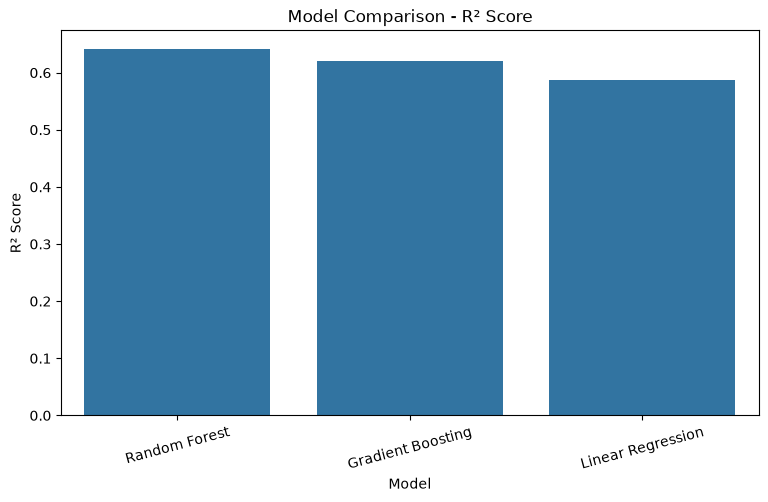

In [37]:
results_sorted = results_df.sort_values(
    "R2 Score",
    ascending=False
)

display(results_sorted)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=results_sorted,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.show()

In [38]:
best_model_name = results_sorted.iloc[0]["Model"]

print("Best initial model:", best_model_name)

Best initial model: Random Forest


Hyperparameter tuning

In [53]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

train_predictions = rf_pipeline.predict(X_train)
test_predictions = rf_pipeline.predict(X_test)

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print("Random Forest")
print("-------------")
print("Training R2:", train_r2)
print("Testing R2:", test_r2)
print("Difference:", train_r2 - test_r2)

Random Forest
-------------
Training R2: 0.9493707123681397
Testing R2: 0.6418774568219598
Difference: 0.3074932555461799


In [55]:
# Convert log predictions back to actual prices

predicted_prices = np.expm1(test_predictions)
actual_prices = np.expm1(y_test)

mae = mean_absolute_error(
    actual_prices,
    predicted_prices
)

rmse = np.sqrt(
    mean_squared_error(
        actual_prices,
        predicted_prices
    )
)

r2 = r2_score(
    actual_prices,
    predicted_prices
)

print("Model Performance")
print("-----------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 4))

Model Performance
-----------------
MAE : 41.93
RMSE: 73.16
R2  : 0.4973


In [56]:
import joblib

joblib.dump(
    rf_pipeline,
    "../airbnb_price_pipeline.pkl"
)

print("Model pipeline saved successfully.")

Model pipeline saved successfully.


In [58]:
model_results = pd.DataFrame({
    "Metric": [
        "Training R2",
        "Testing R2",
        "R2 Difference",
        "MAE",
        "RMSE"
    ],
    "Value": [
        train_r2,
        test_r2,
        train_r2 - test_r2,
        mae,
        rmse
    ]
})

display(model_results)

model_results.to_csv(
    "../final_model_results.csv",
    index=False
)

print("Final model results saved successfully.")

,Metric,Value
0,Training R2,0.949371
1,Testing R2,0.641877
2,R2 Difference,0.307493
3,MAE,41.933146
4,RMSE,73.162896


Final model results saved successfully.


In [59]:
results_df.to_csv(
    "../model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.
